# Read outputs

In [17]:
import pandas as pd
import numpy as np

def read_output(filename):
    with open(filename, "r") as f:
        out = f.readlines()
    out = [e.strip() for e in out if e.startswith("Iter")]
    out_dict = [{e.strip().split()[0]: float(e.strip().split()[1]) for e in line.split(",")} for line in out]
    df = pd.DataFrame(out_dict)

    # add the trails (should be 10)
    curr_trial = -1
    for i in range(len(df)):
        if df.loc[i, "Iter"] == 0:
            curr_trial += 1
        df.loc[i, "trial"] = curr_trial
    df["trial"] = df["trial"].astype(int)
    return df

In [18]:
natsr_df = read_output("synthetic_output_runs/output_outlier_natsr.txt")
ogd_df = read_output("synthetic_output_runs/output_outlier_ogd.txt")
er_df = read_output("synthetic_output_runs/output_outlier_er.txt")

In [19]:
natsr_df.head()

,Iter,pred_0,pred_1,true,scale,tau,mse,mae,orig_grad_norm,reg_grad_norm,trial
0,0.0,0.872469,0.928498,2.578413,1.2064,0.9405,97.5871,7.7859,65.1415,3.7330,0
1,1.0,1.059885,0.693023,-12.937433,1.4423,0.9405,99.7763,7.9510,50.5493,2.8181,0
2,2.0,1.434461,-0.642357,2.597668,1.6331,0.9405,5.7351,2.1720,32.6050,2.4802,0
3,3.0,1.294991,0.350135,2.538381,1.7896,0.9405,3.0919,1.6985,17.8302,2.0520,0
4,4.0,1.489178,0.224865,2.503704,1.9231,0.9405,3.0869,1.6413,15.9449,1.6985,0


In [20]:
natsr_df.tail()

,Iter,pred_0,pred_1,true,scale,tau,mse,mae,orig_grad_norm,reg_grad_norm,trial
10605,1056.0,10.358704,10.407709,5.498728,1.5085,0.9405,23.8493,4.8835,165.8669,2.2445,9
10606,1057.0,6.988927,7.061151,5.500644,1.5162,0.9405,2.3694,1.5385,57.8558,2.2117,9
10607,1058.0,6.526929,6.456765,5.472504,1.5267,0.9405,1.0282,1.0132,40.0235,2.2827,9
10608,1059.0,5.856840,5.827300,5.484875,1.5239,0.9405,0.1295,0.3596,15.4610,2.1107,9
10609,1060.0,5.608218,5.514230,5.479988,1.5156,0.9405,0.0127,0.1116,5.1308,1.8191,9


# Plots

Trial: 0


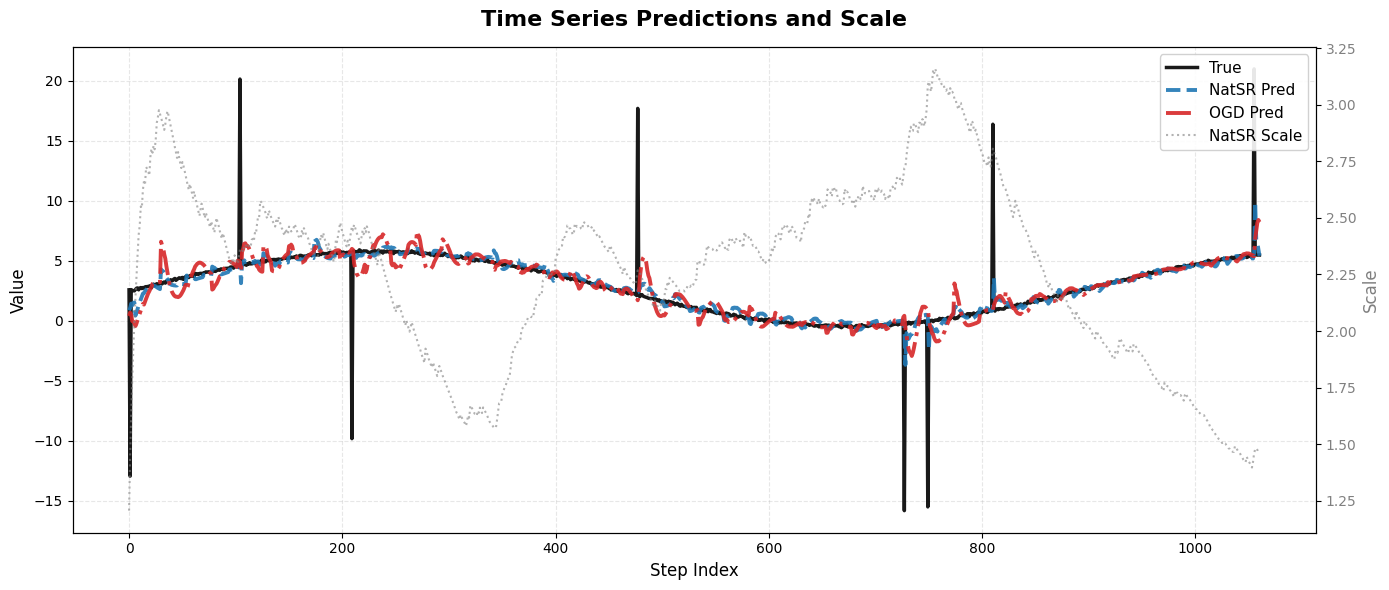

Trial: 1


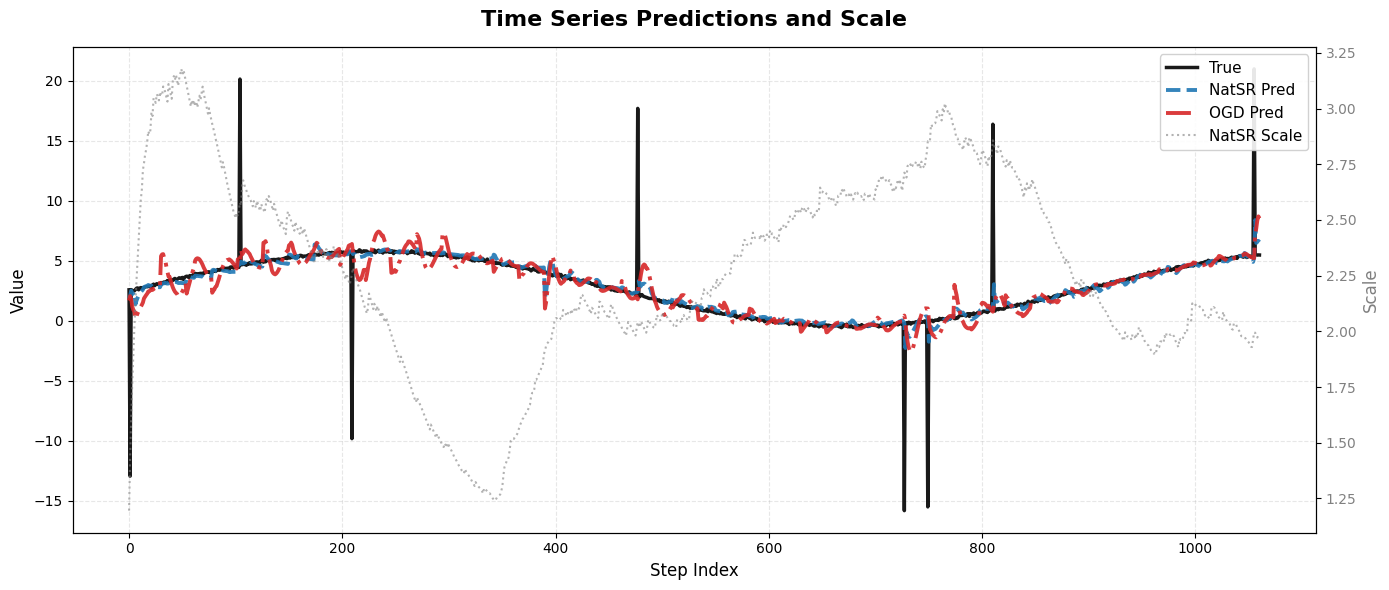

Trial: 2


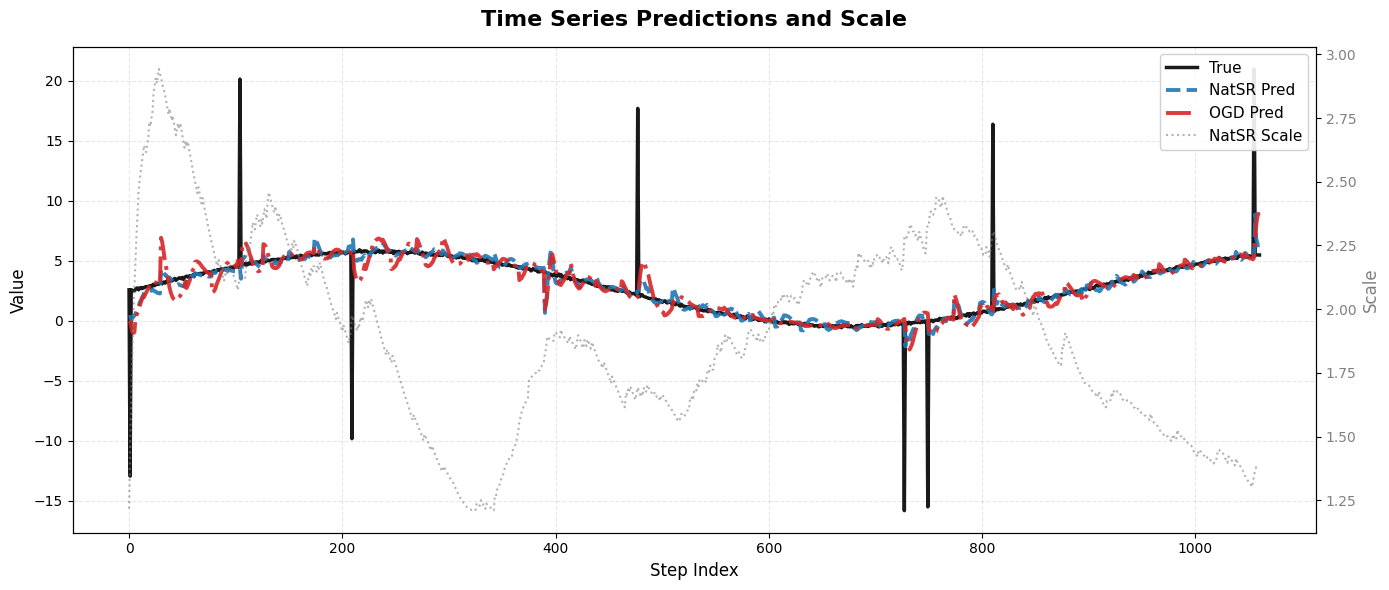

Trial: 3


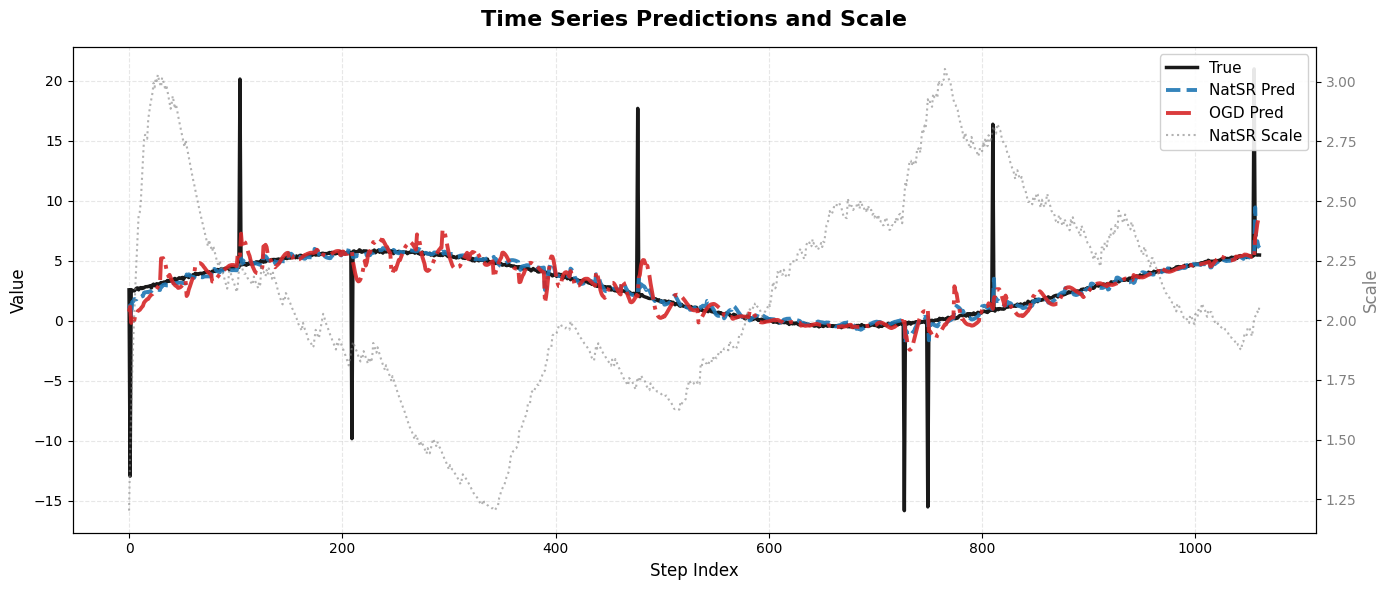

Trial: 4


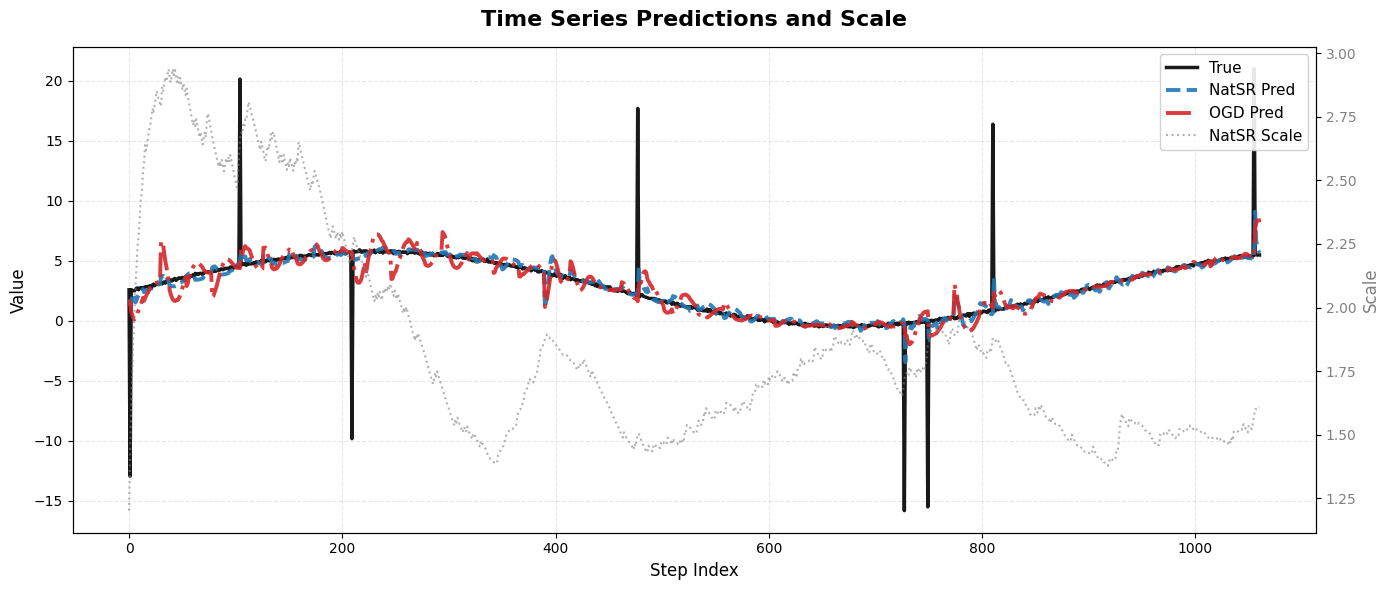

Trial: 5


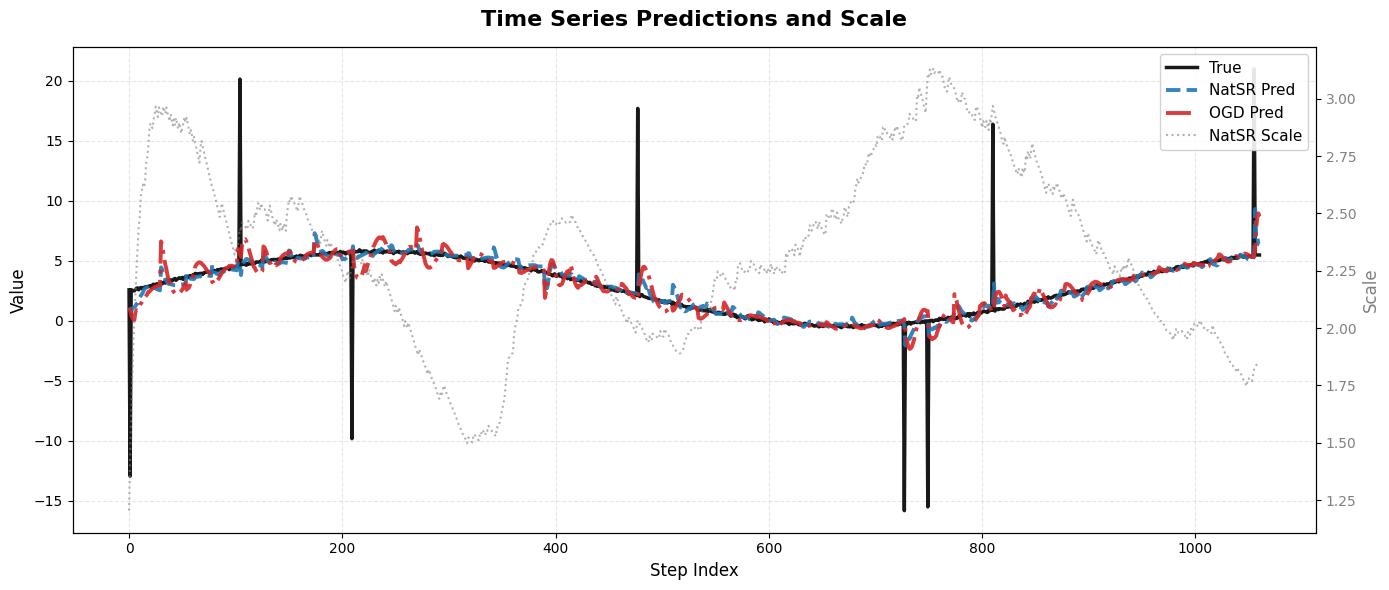

Trial: 6


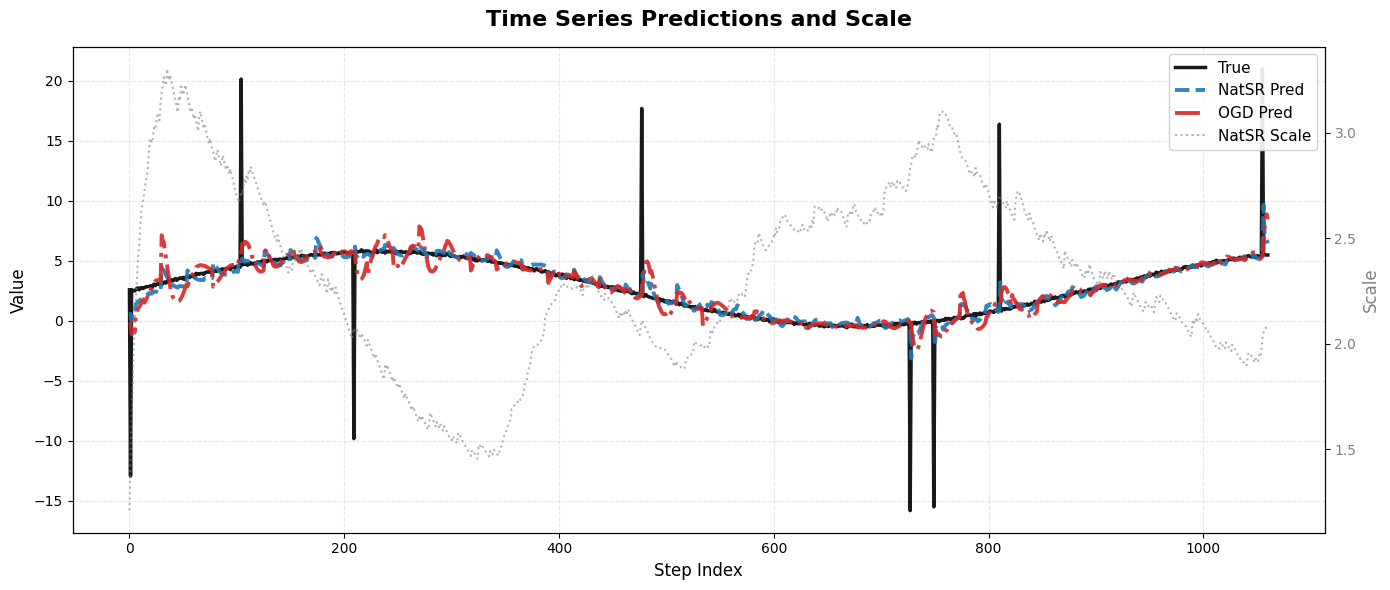

Trial: 7


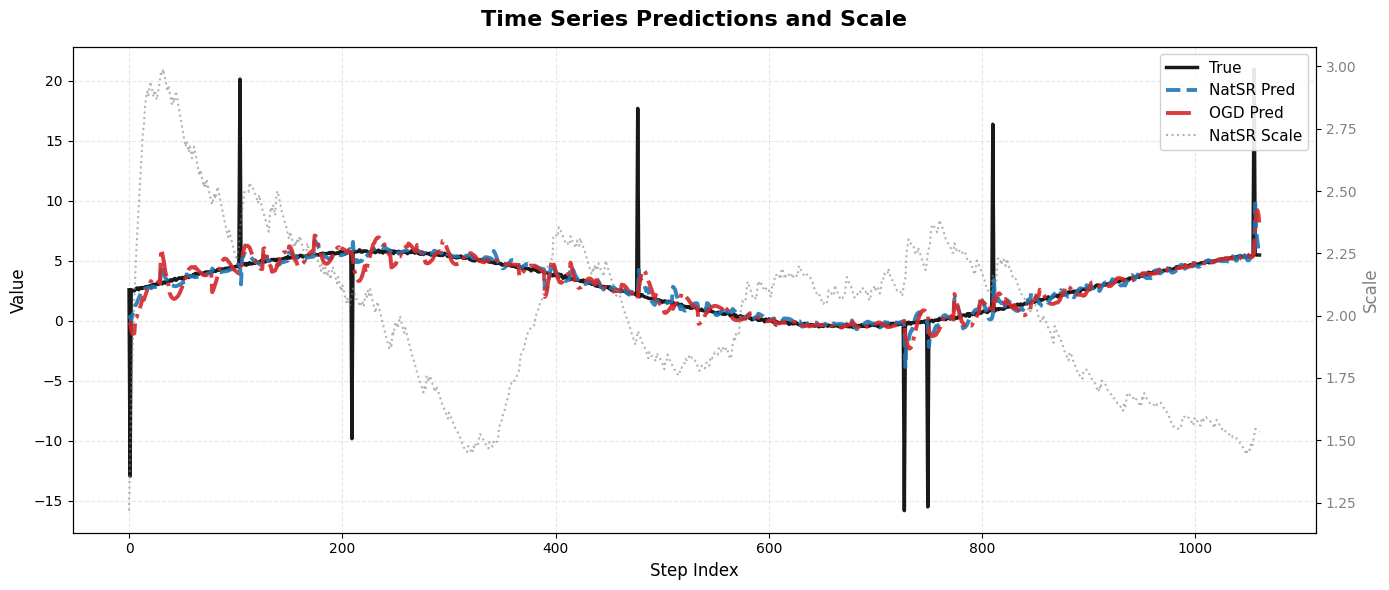

Trial: 8


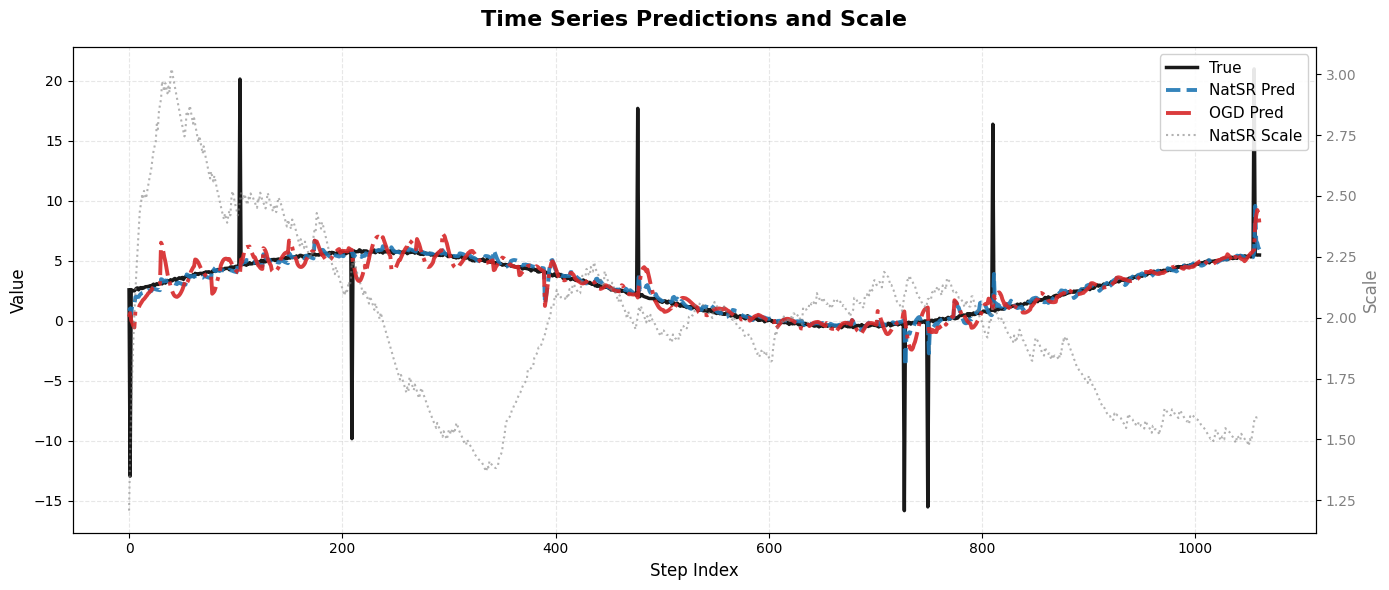

Trial: 9


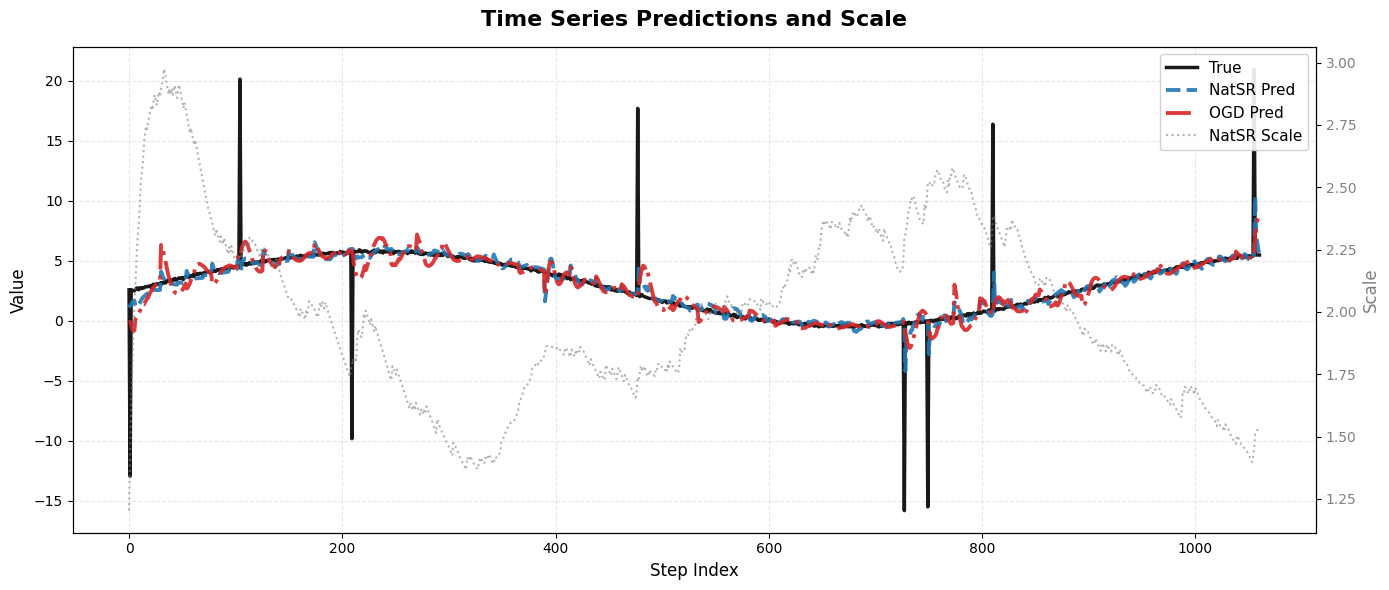

In [21]:
import matplotlib.pyplot as plt

for trial in natsr_df["trial"].unique():
    print(f"Trial: {trial}")
    natsr_df_trial = natsr_df[natsr_df["trial"] == trial]
    ogd_df_trial = ogd_df[ogd_df["trial"] == trial]

    fig, ax1 = plt.subplots(figsize=(14, 6))

    x = range(len(natsr_df_trial))

    # --- Left Y-axis: true + predictions ---
    ax1.plot(
        x, natsr_df_trial['true'], 
        label='True', 
        color='black', 
        linestyle='-', 
        linewidth=2.5, 
        alpha=0.9, 
        zorder=3
    )
    ax1.plot(
        x, natsr_df_trial['pred_0'], 
        label='NatSR Pred', 
        color='#1f77b4',   # bright blue
        linestyle='--', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )
    ax1.plot(
        x, ogd_df_trial['pred_0'], 
        label='OGD Pred', 
        color='#d62728',   # vivid red
        linestyle='-.', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )

    ax1.set_xlabel('Step Index', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.tick_params(axis='both')
    ax1.grid(True, linestyle='--', alpha=0.3, zorder=1)

    # --- Right Y-axis: scale (make subtle) ---
    ax2 = ax1.twinx()
    ax2.plot(
        x, natsr_df_trial['scale'], 
        label='NatSR Scale', 
        color='gray', 
        linestyle=':', 
        linewidth=1.5, 
        alpha=0.6, 
        zorder=2
    )
    ax2.set_ylabel('Scale', fontsize=12, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    # --- Legend ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines_1 + lines_2, labels_1 + labels_2, 
        loc='upper right', 
        fontsize=11, 
        frameon=True, 
        fancybox=True, 
        framealpha=0.9
    )

    # --- Title ---
    plt.title('Time Series Predictions and Scale', fontsize=16, weight='bold', pad=15)

    plt.tight_layout()
    plt.show()


Trial: 0


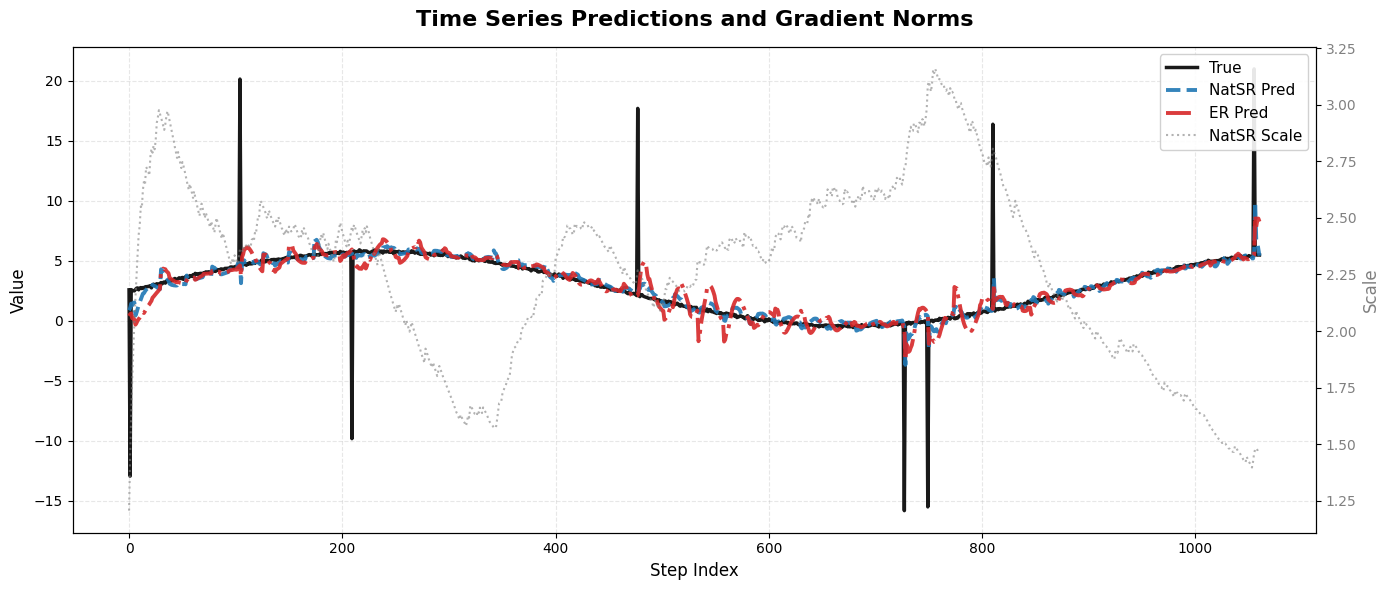

Trial: 1


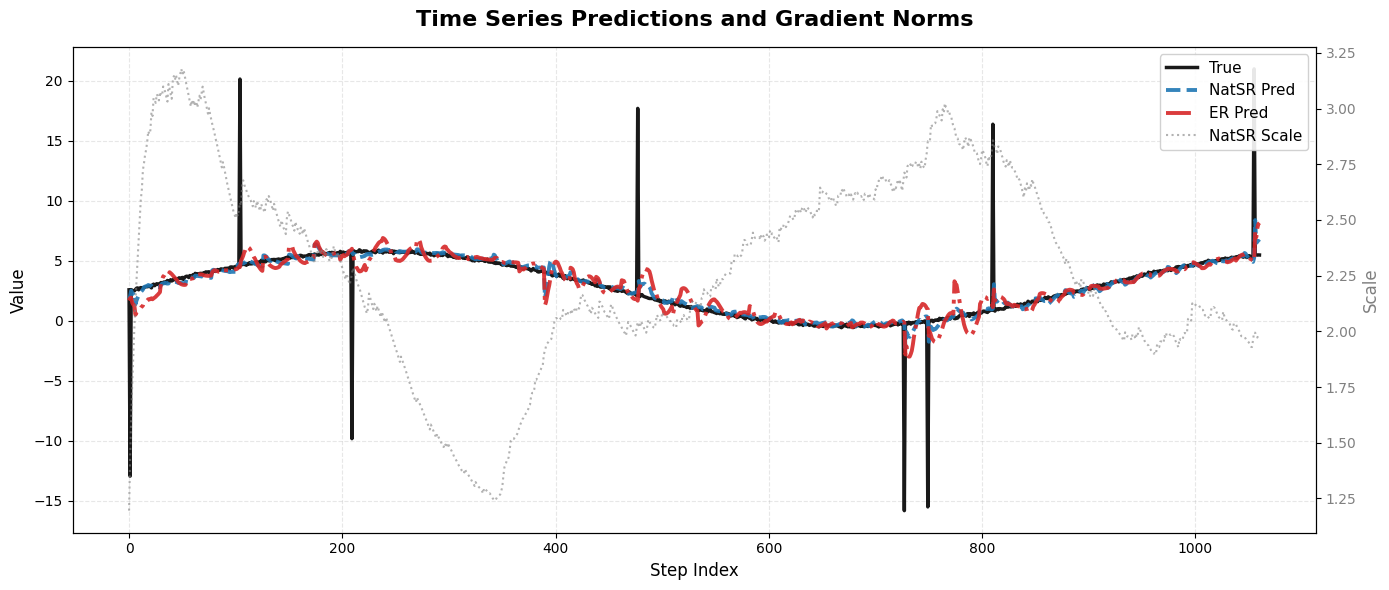

Trial: 2


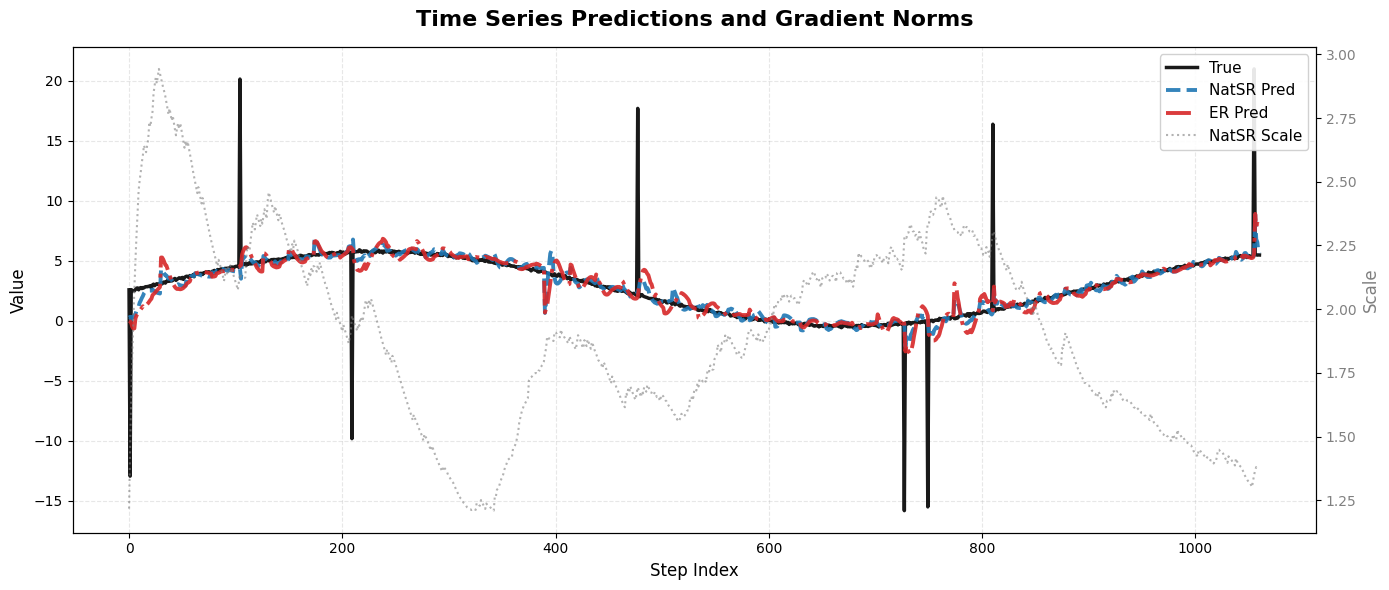

Trial: 3


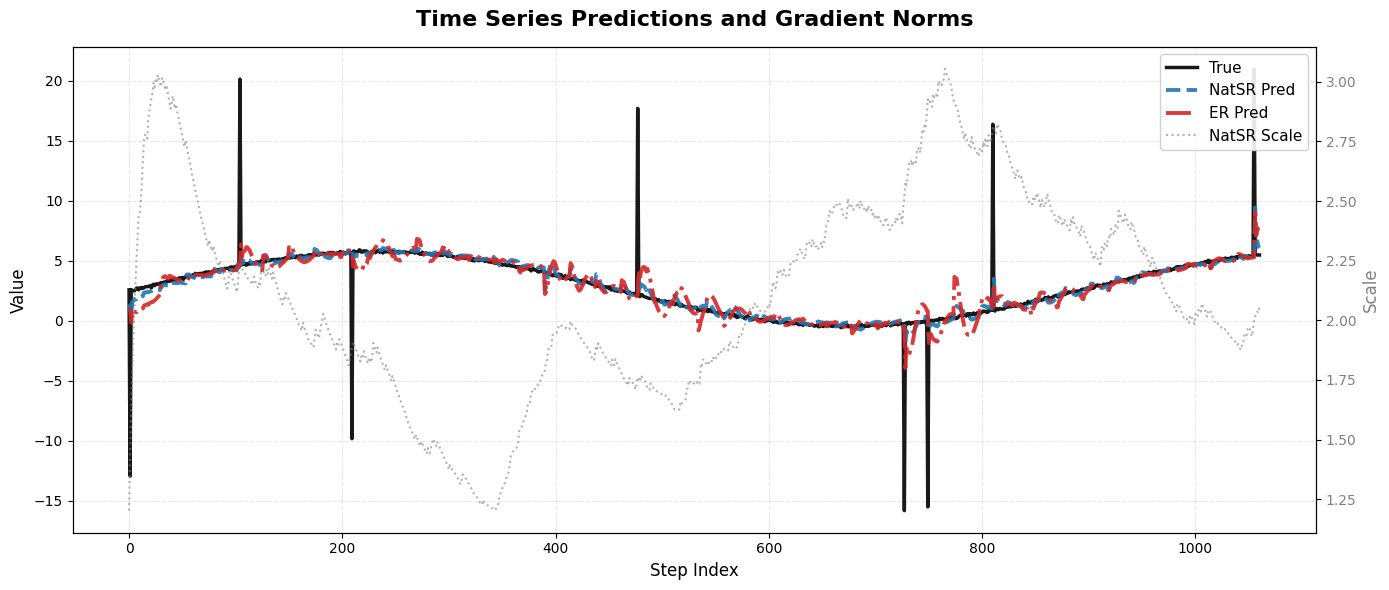

Trial: 4


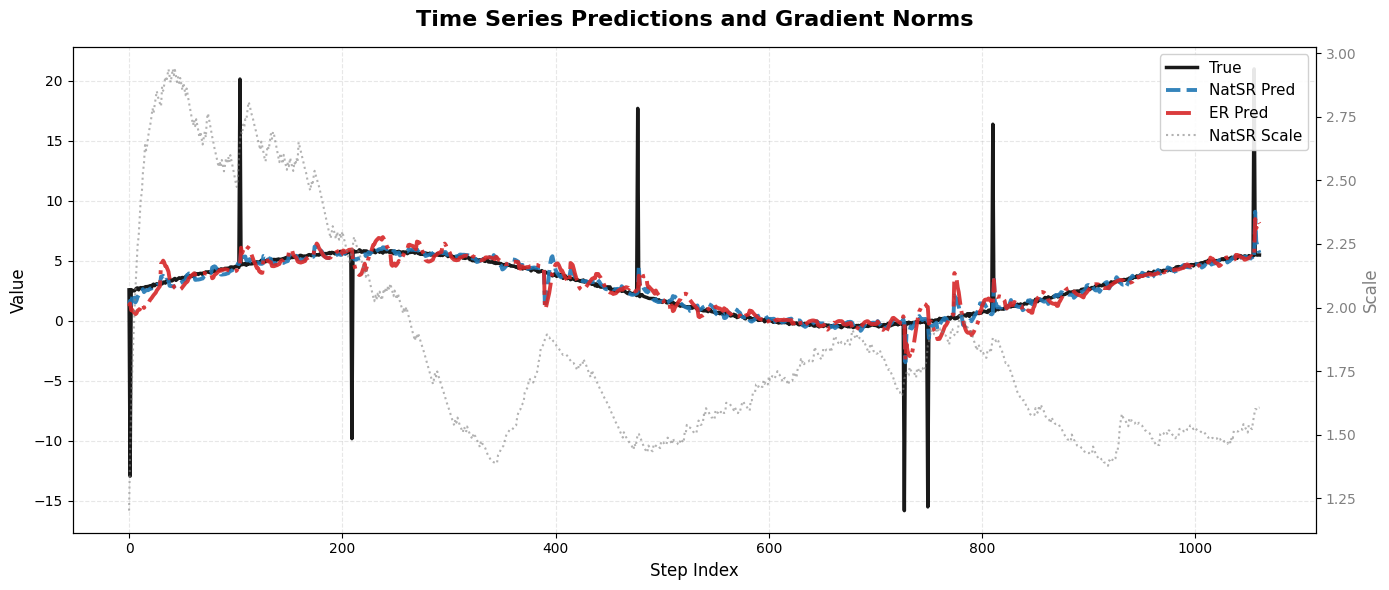

Trial: 5


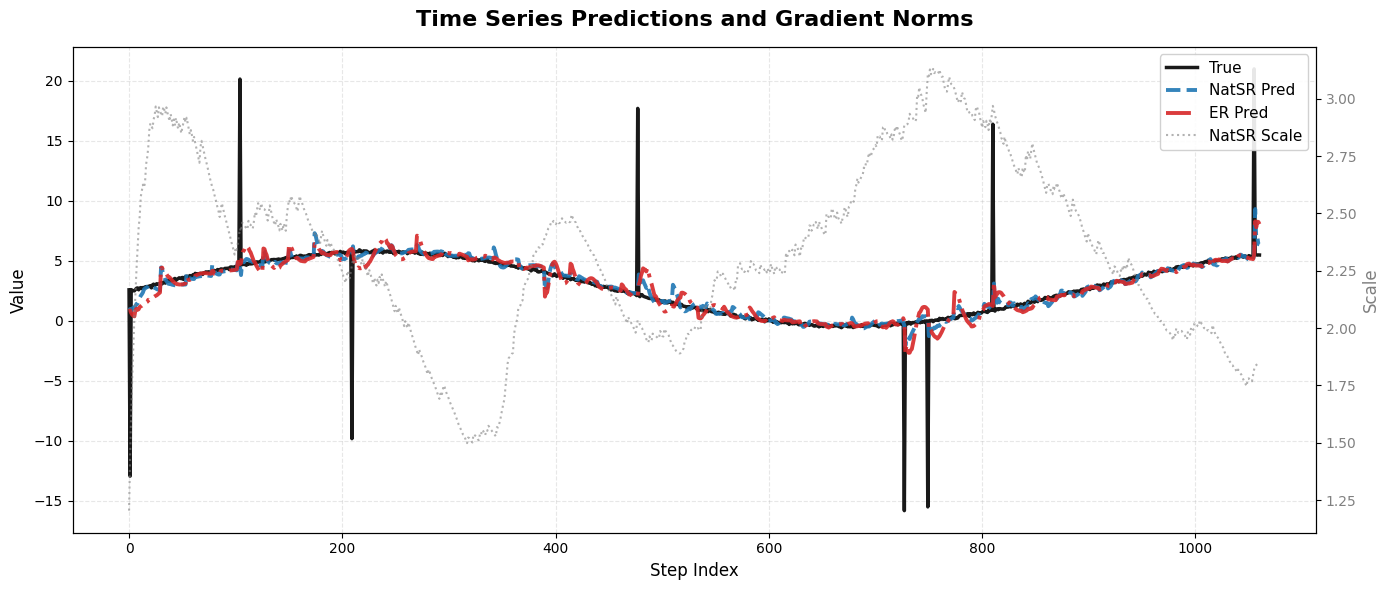

Trial: 6


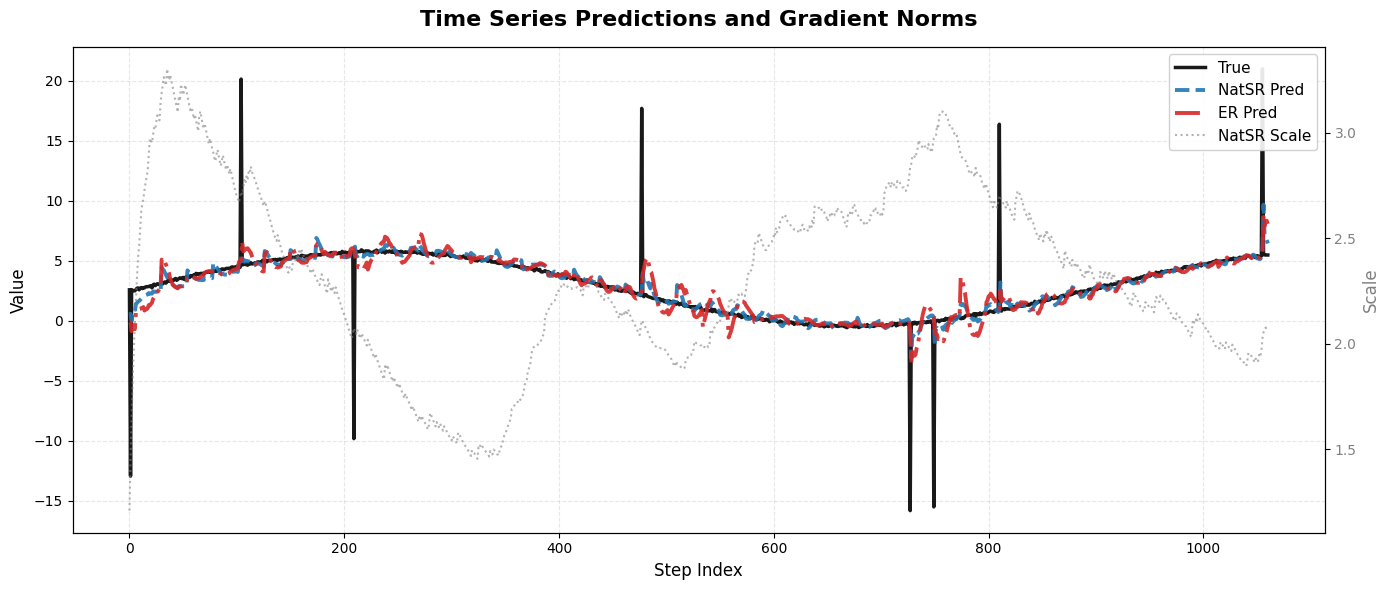

Trial: 7


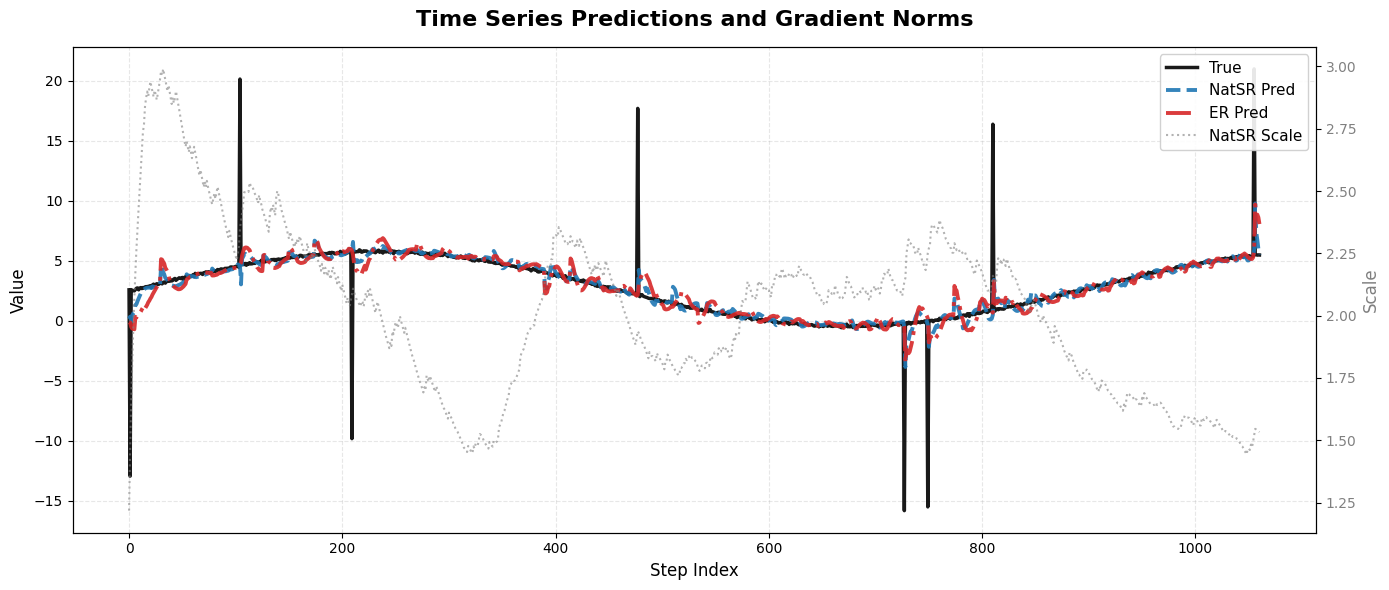

Trial: 8


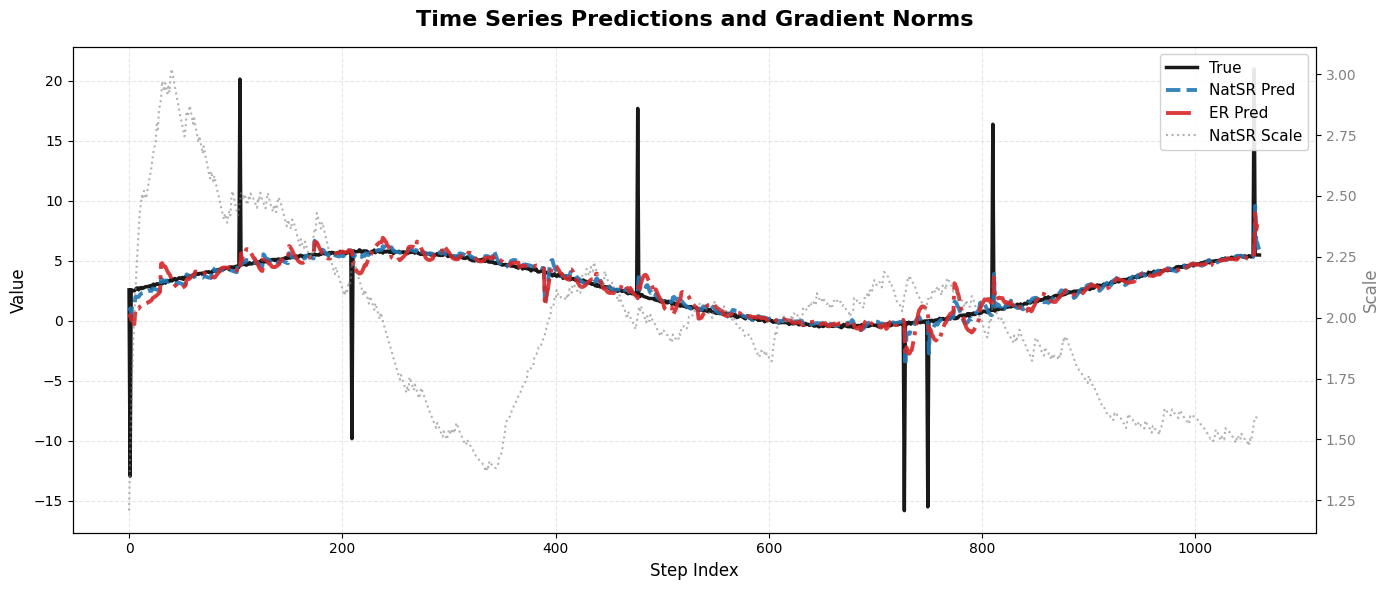

Trial: 9


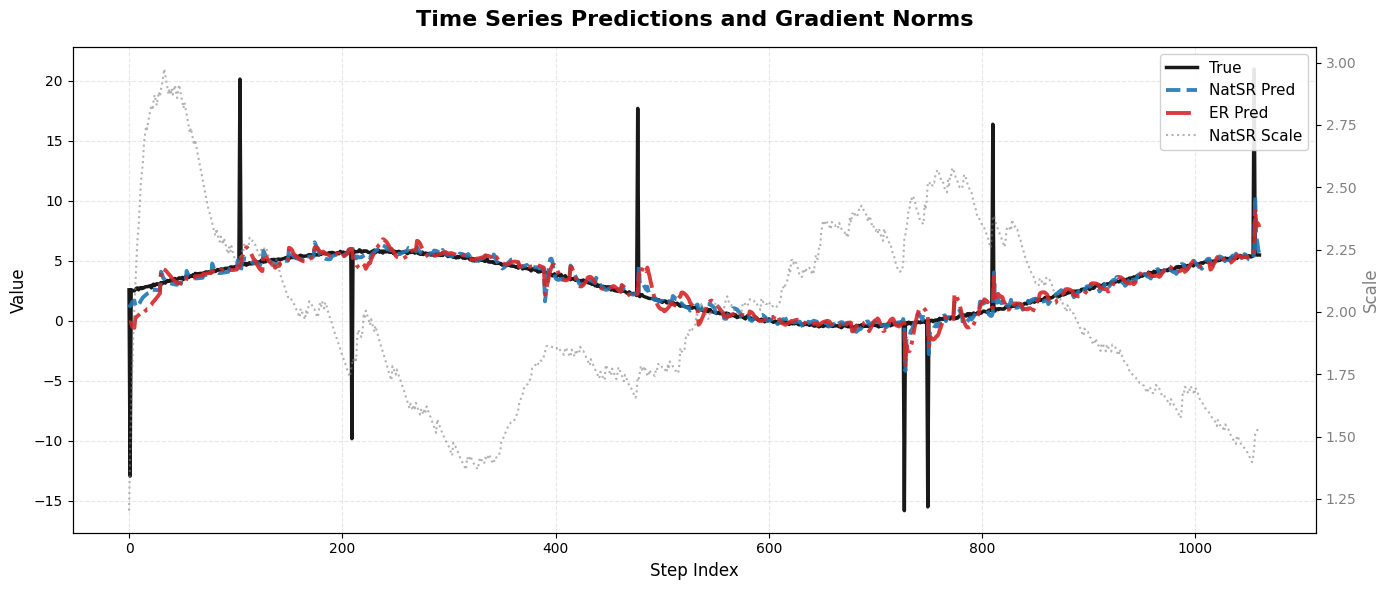

In [22]:
for trial in natsr_df["trial"].unique():
    print(f"Trial: {trial}")
    natsr_df_trial = natsr_df[natsr_df["trial"] == trial]
    ogd_df_trial = ogd_df[ogd_df["trial"] == trial]
    er_df_trial = er_df[er_df["trial"] == trial]

    fig, ax1 = plt.subplots(figsize=(14, 6))

    x = range(len(natsr_df_trial))

    # --- Left Y-axis: true + predictions ---
    ax1.plot(
        x, natsr_df_trial['true'], 
        label='True', 
        color='black', 
        linestyle='-', 
        linewidth=2.5, 
        alpha=0.9, 
        zorder=3
    )
    ax1.plot(
        x, natsr_df_trial['pred_0'], 
        label='NatSR Pred', 
        color='#1f77b4',   # bright blue
        linestyle='--', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )
    ax1.plot(
        x, er_df_trial['pred_0'], 
        label='ER Pred', 
        color='#d62728',   # vivid red
        linestyle='-.', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )

    ax1.set_xlabel('Step Index', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.tick_params(axis='both')
    ax1.grid(True, linestyle='--', alpha=0.3, zorder=1)

    # --- Right Y-axis: scale (make subtle) ---
    ax2 = ax1.twinx()
    ax2.plot(
        x, natsr_df_trial['scale'], 
        label='NatSR Scale', 
        color='gray', 
        linestyle=':', 
        linewidth=1.5, 
        alpha=0.6, 
        zorder=2
    )
    ax2.set_ylabel('Scale', fontsize=12, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    # --- Legend ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines_1 + lines_2, labels_1 + labels_2, 
        loc='upper right', 
        fontsize=11, 
        frameon=True, 
        fancybox=True, 
        framealpha=0.9
    )

    # --- Title ---
    plt.title('Time Series Predictions and Gradient Norms', fontsize=16, weight='bold', pad=15)

    plt.tight_layout()
    plt.show()


# Plot Statistics of different trials

In [23]:
real_ts = ogd_df[ogd_df["trial"] == 0]["true"]
# natsr
mean_pred_natsr = natsr_df.groupby('Iter')['pred_0'].mean()
q1_pred_natsr = natsr_df.groupby('Iter')['pred_0'].quantile(0.25)
q3_pred_natsr = natsr_df.groupby('Iter')['pred_0'].quantile(0.75)
std_pred_natsr = natsr_df.groupby('Iter')['pred_0'].std()
mean_grad_natsr = natsr_df.groupby('Iter')['reg_grad_norm'].mean()
# ogd
mean_pred_ogd = ogd_df.groupby('Iter')['pred_0'].mean()
q1_pred_ogd = ogd_df.groupby('Iter')['pred_0'].quantile(0.25)
q3_pred_ogd = ogd_df.groupby('Iter')['pred_0'].quantile(0.75)
std_pred_ogd = ogd_df.groupby('Iter')['pred_0'].std()
mean_grad_ogd = ogd_df.groupby('Iter')['orig_grad_norm'].mean()
# er
mean_pred_er = er_df.groupby('Iter')['pred_0'].mean()
q1_pred_er = er_df.groupby('Iter')['pred_0'].quantile(0.25)
q3_pred_er = er_df.groupby('Iter')['pred_0'].quantile(0.75)
std_pred_er = er_df.groupby('Iter')['pred_0'].std()
mean_grad_er = er_df.groupby('Iter')['orig_grad_norm'].mean()

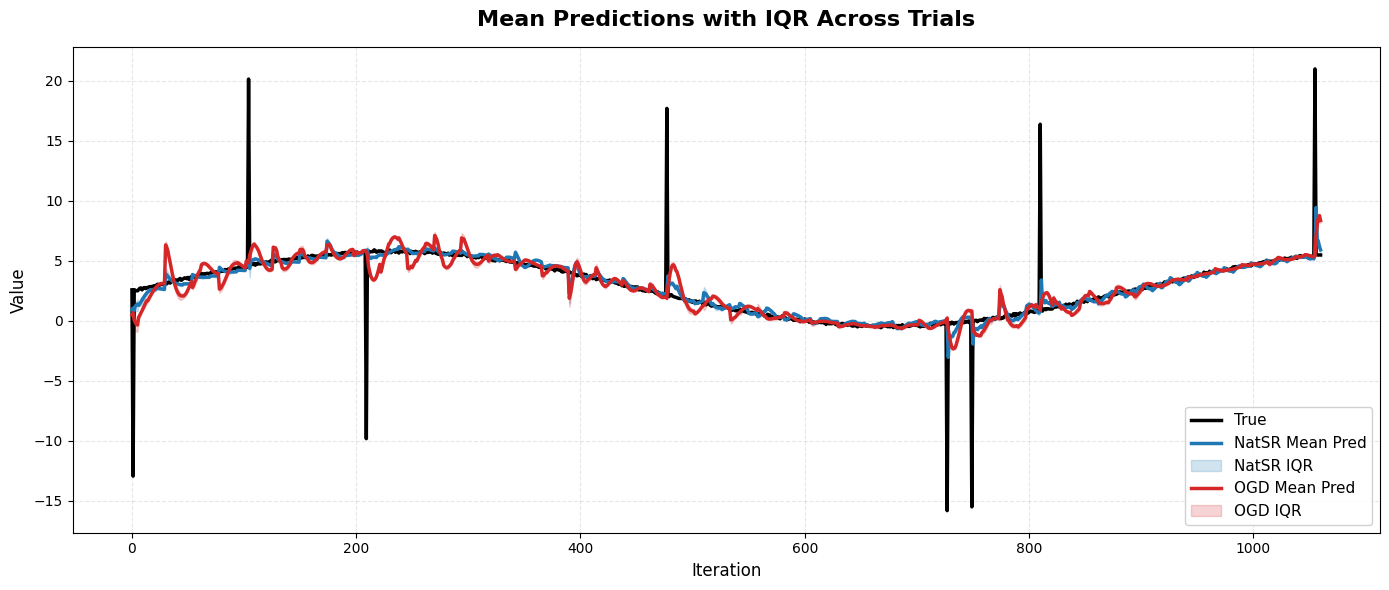

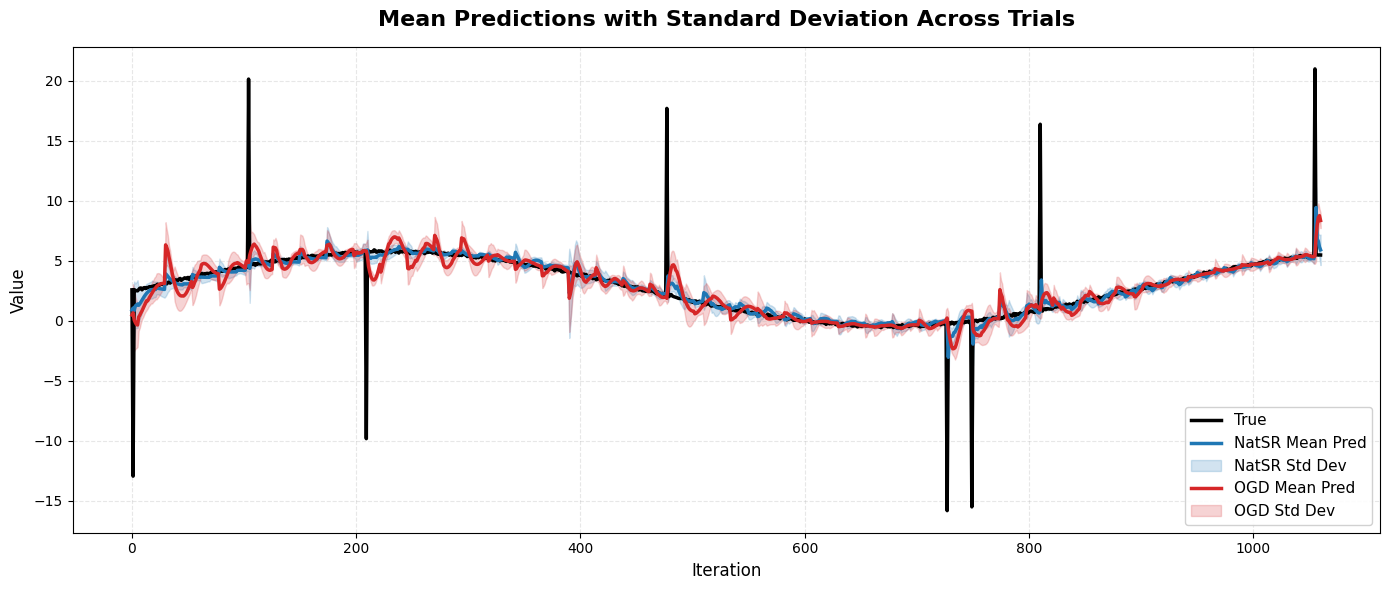

In [24]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=2.5)
plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=2.5)
plt.fill_between(mean_pred_natsr.index, q1_pred_natsr, q3_pred_natsr, color='#1f77b4', alpha=0.2, label='NatSR IQR')
plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=2.5)
plt.fill_between(mean_pred_ogd.index, q1_pred_ogd, q3_pred_ogd, color='#d62728', alpha=0.2, label='OGD IQR')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with IQR Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=2.5)
plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=2.5)
plt.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color='#1f77b4', alpha=0.2, label='NatSR Std Dev')
plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=2.5)
plt.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd, color='#d62728', alpha=0.2, label='OGD Std Dev')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

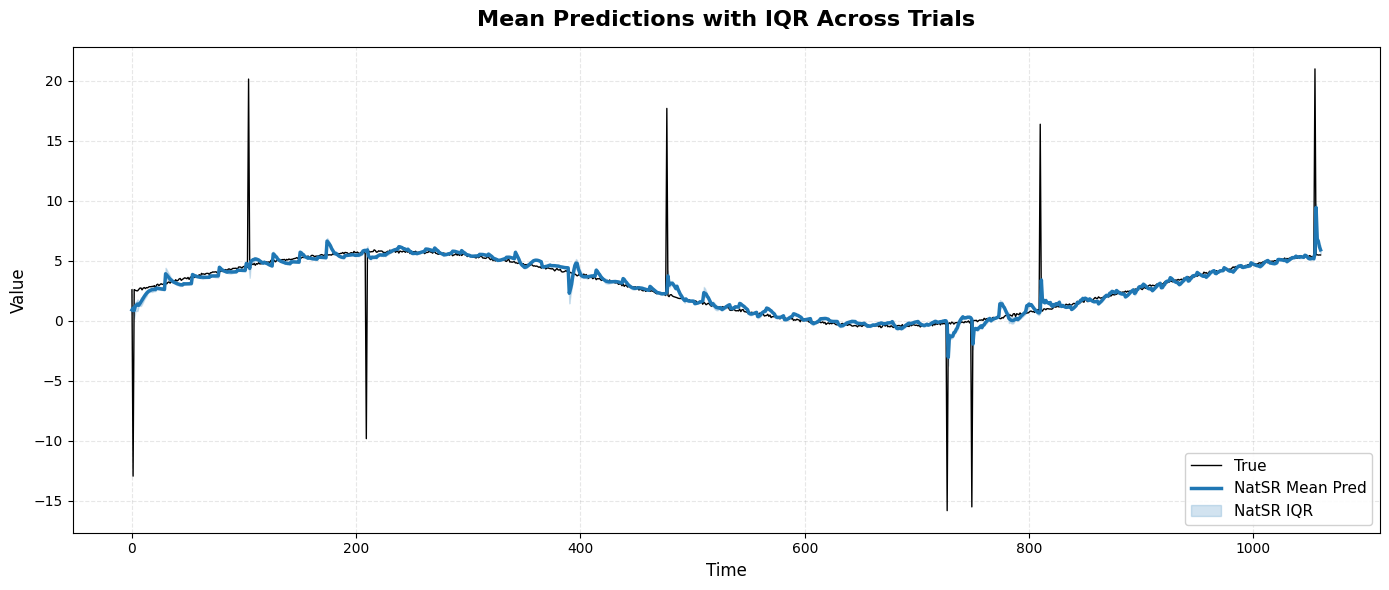

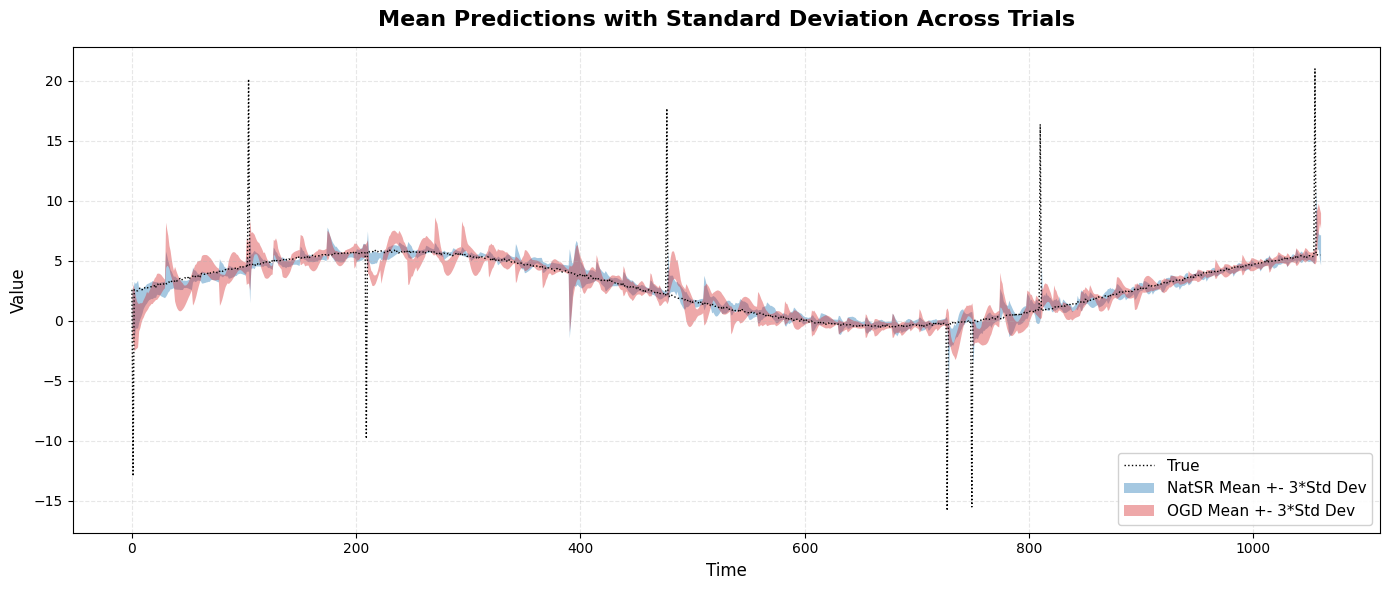

In [25]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=1)
plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=2.5)
plt.fill_between(mean_pred_natsr.index, q1_pred_natsr, q3_pred_natsr, color='#1f77b4', alpha=0.2, label='NatSR IQR')
# plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=2.5)
# plt.fill_between(mean_pred_ogd.index, q1_pred_ogd, q3_pred_ogd, color='#d62728', alpha=0.2, label='OGD IQR')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with IQR Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=1, linestyle='dotted')
#plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=1)
plt.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color='#1f77b4', alpha=0.4, label='NatSR Mean +- 3*Std Dev', linewidth=0)
#plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=1)
plt.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd, color='#d62728', alpha=0.4, label='OGD Mean +- 3*Std Dev', linewidth=0)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Final Plots

In [26]:
mean_alpha = 0.6
natsr_col = '#00929c'
other_col = "#df5151"

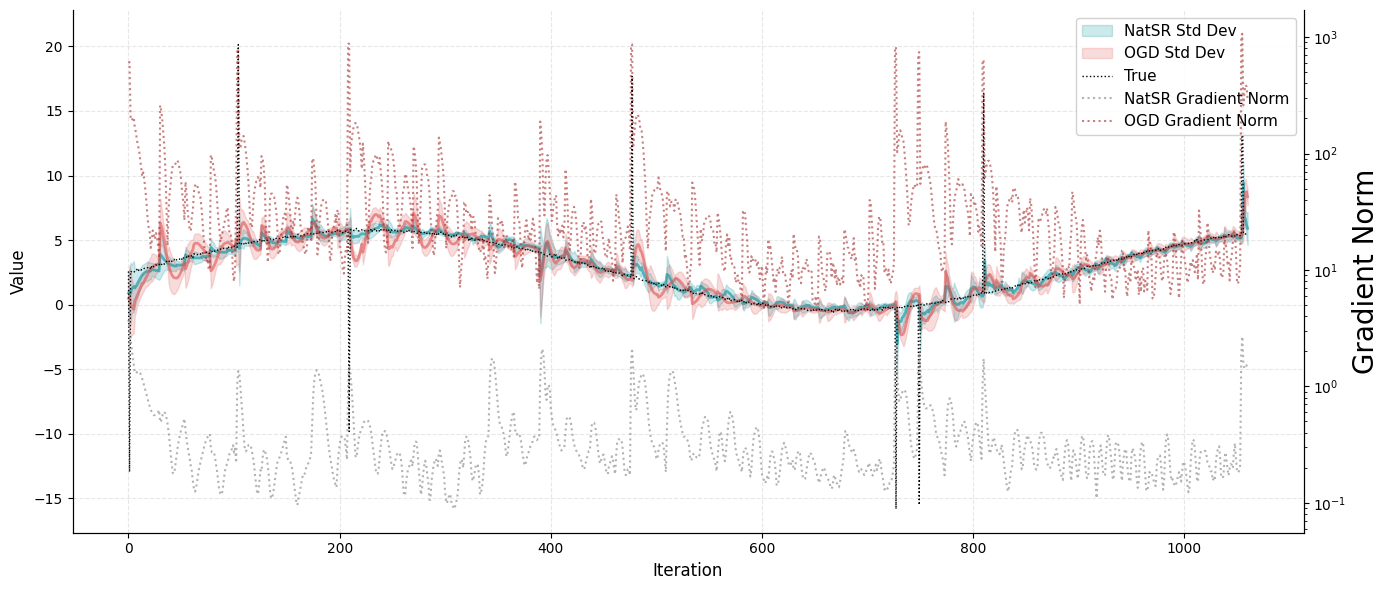

In [27]:
# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color=natsr_col, alpha=0.2, label='NatSR Std Dev')
ax1.plot(mean_pred_ogd.index, mean_pred_ogd, color=other_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd, color=other_col, alpha=0.2, label='OGD Std Dev')
ax1.plot(real_ts.index, real_ts, color='black', linewidth=1, linestyle='dotted', label='True')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Value', fontsize=12)
#ax1.set_title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
ax1.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.3)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, mean_grad_natsr, label='NatSR Gradient Norm', color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=2)
ax2.plot(x, mean_grad_ogd, label='OGD Gradient Norm', color='brown', linestyle=':', linewidth=1.5, alpha=0.6, zorder=2)
ax2.set_ylabel('Gradient Norm', fontsize=20)
# log scale for better visibility
ax2.set_yscale('log')

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
plt.show()

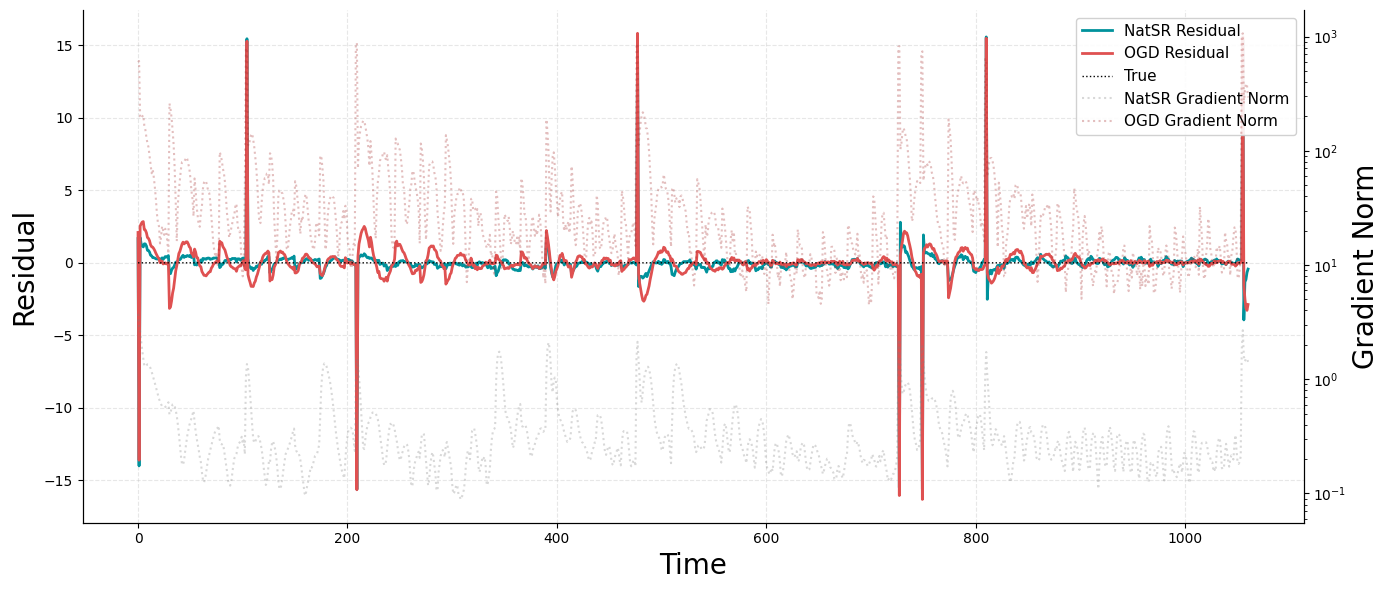

In [28]:
# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(mean_pred_natsr.index, real_ts - mean_pred_natsr, color=natsr_col, linewidth=2, label='NatSR Residual')
#ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color=natsr_col, alpha=0.2, label='NatSR Std Dev')
ax1.plot(mean_pred_ogd.index, real_ts - mean_pred_ogd, color=other_col, linewidth=2, label='OGD Residual')
#ax1.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd, color=other_col, alpha=0.2, label='OGD Std Dev')
ax1.plot(real_ts.index, real_ts - real_ts, color='black', linewidth=1, linestyle='dotted', label='True')
ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Residual', fontsize=20)
#ax1.set_title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
ax1.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.3)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, mean_grad_natsr, label='NatSR Gradient Norm', color='gray', linestyle=':', linewidth=1.5, alpha=0.3)
ax2.plot(x, mean_grad_ogd, label='OGD Gradient Norm', color='brown', linestyle=':', linewidth=1.5, alpha=0.3)
ax2.set_ylabel('Gradient Norm', fontsize=20)
# log scale for better visibility
ax2.set_yscale('log')

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
plt.show()

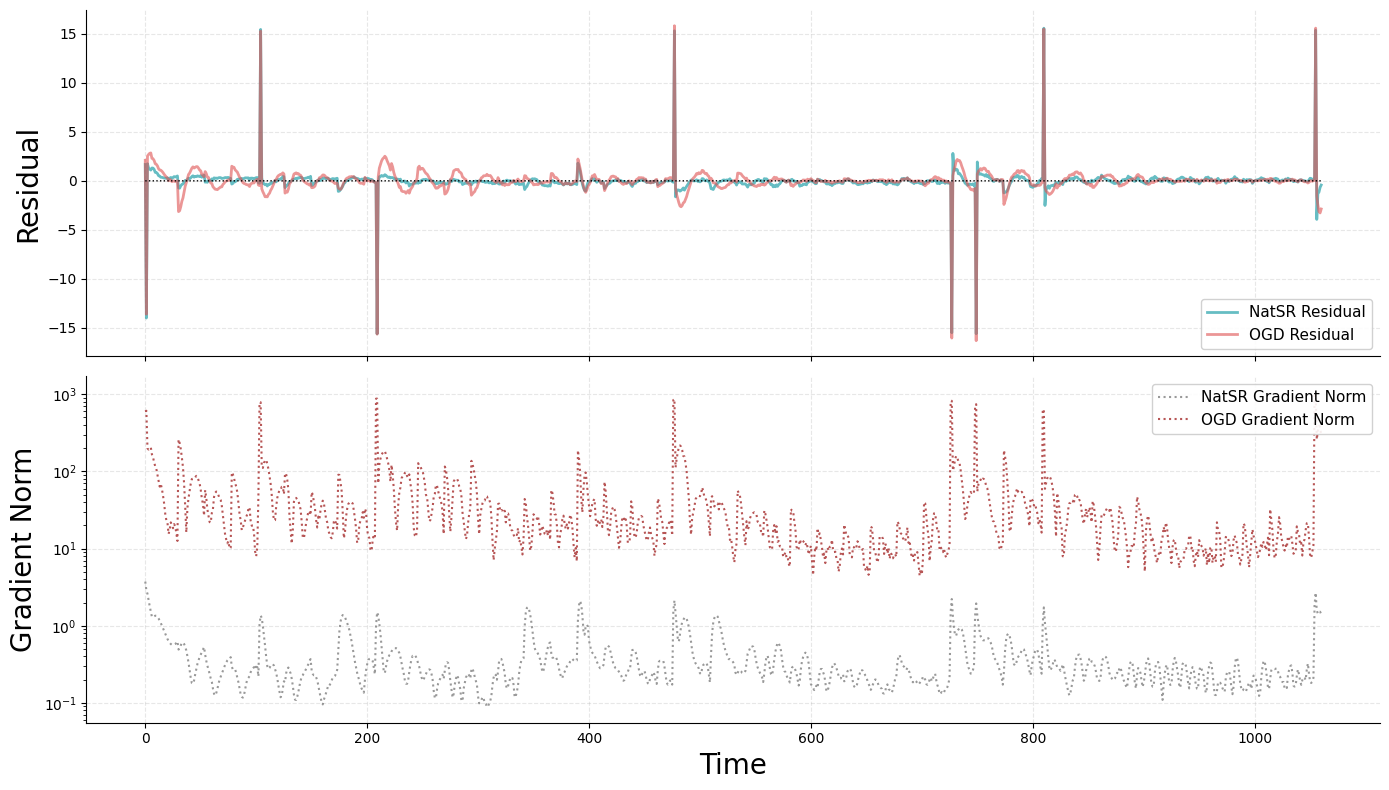

In [29]:
# Create two subplots stacked vertically, sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

# --- First plot: residuals ---
ax1.plot(mean_pred_natsr.index, real_ts - mean_pred_natsr,
         color=natsr_col, linewidth=2, label='NatSR Residual', alpha=mean_alpha)
ax1.plot(mean_pred_ogd.index, real_ts - mean_pred_ogd,
         color=other_col, linewidth=2, label='OGD Residual', alpha=mean_alpha)
ax1.plot(real_ts.index, real_ts - real_ts,
         color='black', linewidth=1, linestyle='dotted')

ax1.set_ylabel('Residual', fontsize=20)
ax1.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.3)

# --- Second plot: gradient norms ---
ax2.plot(x, mean_grad_natsr, label='NatSR Gradient Norm',
         color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax2.plot(x, mean_grad_ogd, label='OGD Gradient Norm',
         color='brown', linestyle=':', linewidth=1.5, alpha=0.8)

ax2.set_xlabel('Time', fontsize=20)
ax2.set_ylabel('Gradient Norm', fontsize=20)
ax2.set_yscale('log')
ax2.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9, loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.3)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.show()


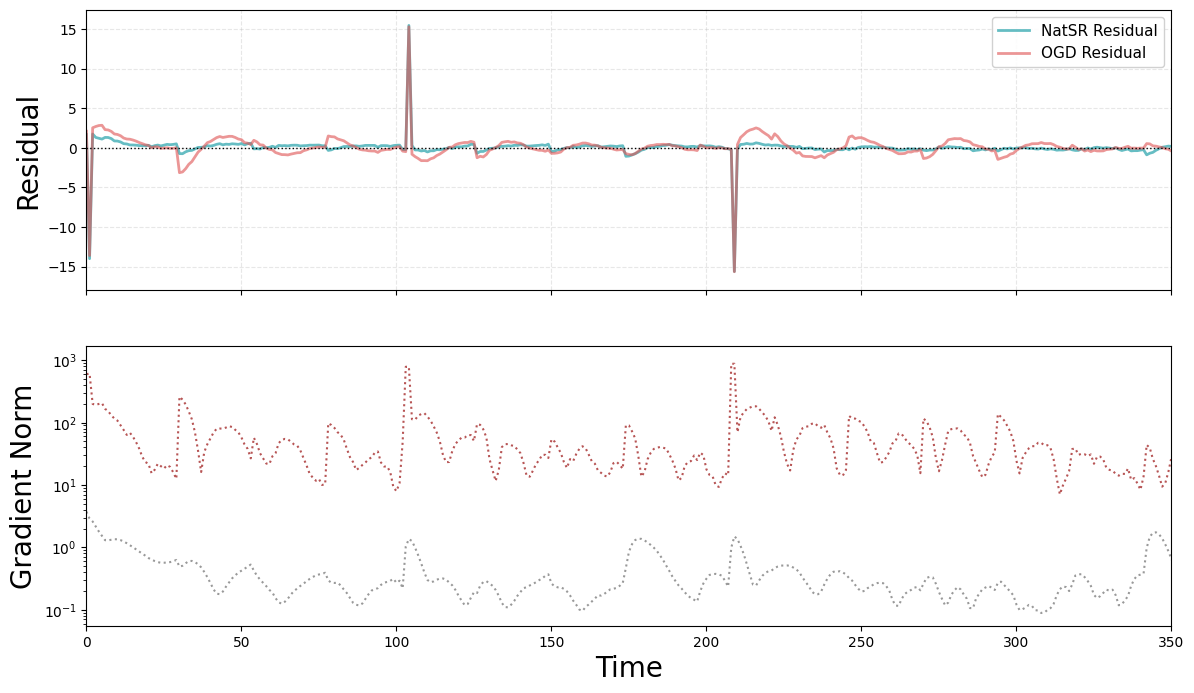

In [30]:
# plot the complete time series with the predictions and the standard deviations, then zoom on the first 350 points and plot errors and gradients
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))
# --- First plot: residuals ---
ax1.plot(mean_pred_natsr.index, real_ts - mean_pred_natsr,
         color=natsr_col, linewidth=2, label='NatSR Residual', alpha=mean_alpha)
ax1.plot(mean_pred_ogd.index, real_ts - mean_pred_ogd,  
         color=other_col, linewidth=2, label='OGD Residual', alpha=mean_alpha)
ax1.plot(real_ts.index, real_ts - real_ts,
         color='black', linewidth=1, linestyle='dotted')
ax1.set_xlim(0, 350)
ax1.set_ylabel('Residual', fontsize=20)
ax1.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.3)
# --- Second plot: gradient norms ---
ax2.plot(x, mean_grad_natsr, label='NatSR Gradient Norm',
         color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax2.plot(x, mean_grad_ogd, label='OGD Gradient Norm',
         color='brown', linestyle=':', linewidth=1.5, alpha=0.8)
ax2.set_xlim(0, 350)
ax2.set_xlabel('Time', fontsize=20)
ax2.set_ylabel('Gradient Norm', fontsize=20)
ax2.set_yscale('log')



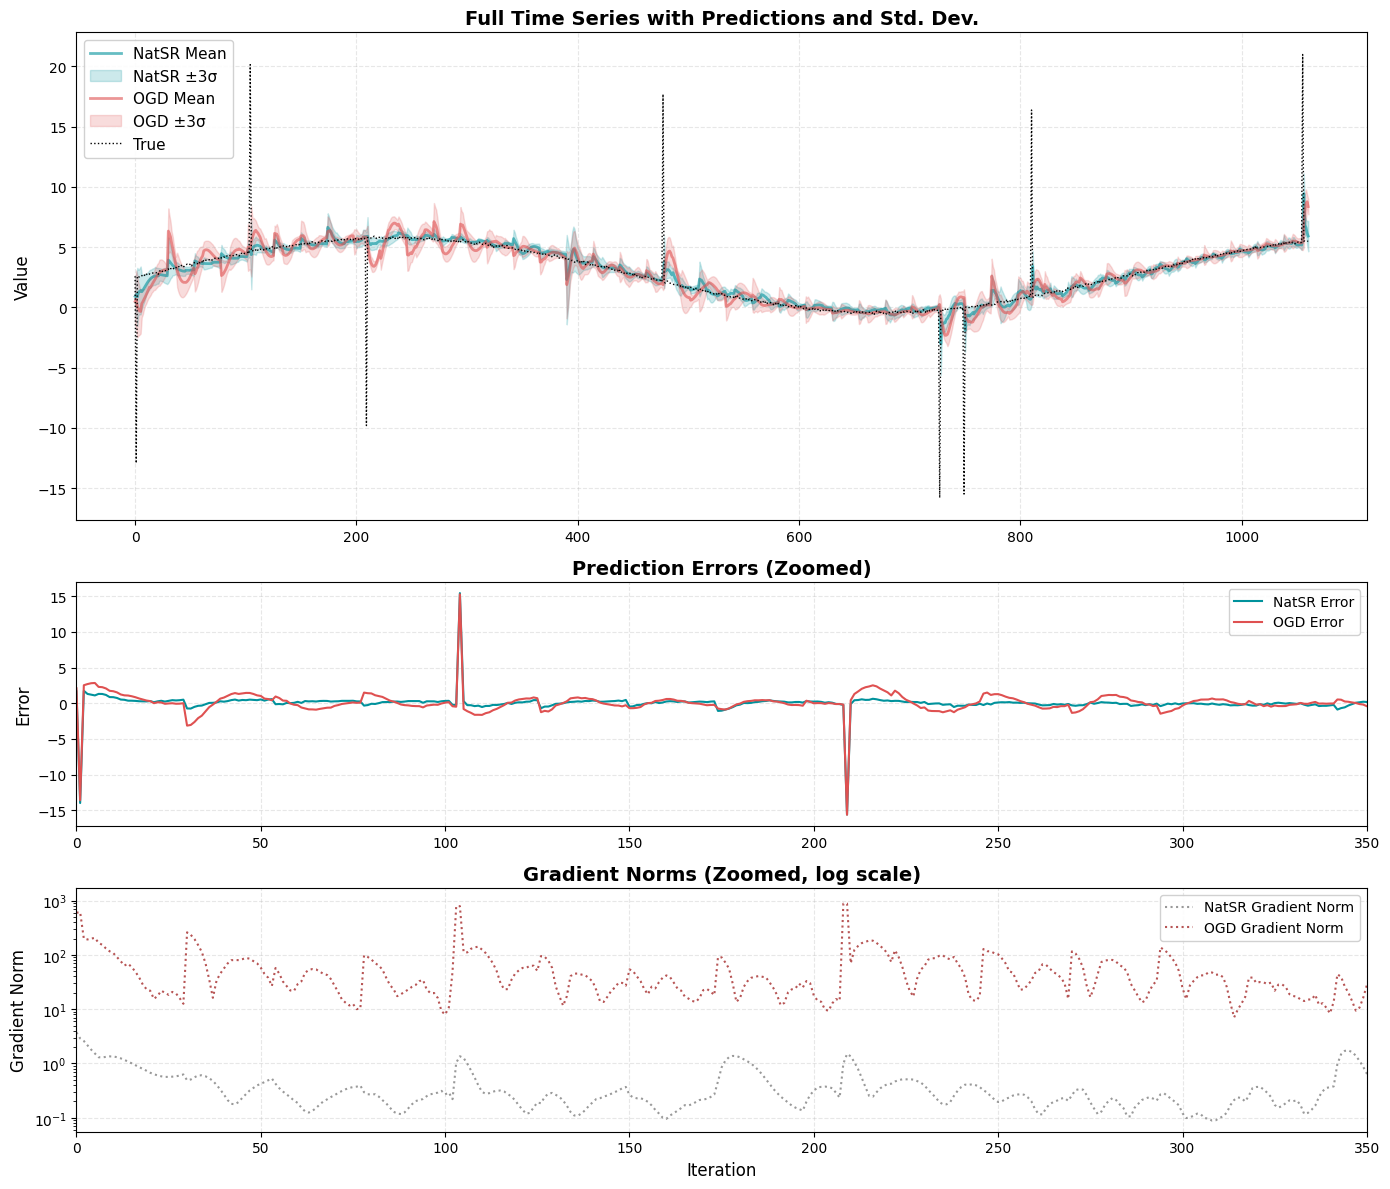

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=False)

# ---------------- Plot 1: Full Time Series ----------------
ax1 = axs[0]

# Predictions + confidence regions
ax1.plot(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, linewidth=2, alpha=mean_alpha, label='NatSR Mean')
ax1.fill_between(mean_pred_natsr.index,
                 mean_pred_natsr - 3*std_pred_natsr,
                 mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.2, label='NatSR ±3σ')

ax1.plot(mean_pred_ogd.index, mean_pred_ogd, color=other_col, linewidth=2, alpha=mean_alpha, label='OGD Mean')
ax1.fill_between(mean_pred_ogd.index,
                 mean_pred_ogd - 3*std_pred_ogd,
                 mean_pred_ogd + 3*std_pred_ogd,
                 color=other_col, alpha=0.2, label='OGD ±3σ')

# True values
ax1.plot(real_ts.index, real_ts, color='black', linewidth=1, linestyle='dotted', label='True')

ax1.set_ylabel('Value', fontsize=12)
ax1.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_title('Full Time Series with Predictions and Std. Dev.', fontsize=14, weight='bold')

# ---------------- Plot 2: Errors (Zoomed x=[0, 350]) ----------------
ax2 = axs[1]
zoom_range = (0, 350)

# Compute errors
error_natsr = real_ts.loc[zoom_range[0]:zoom_range[1]] - mean_pred_natsr.loc[zoom_range[0]:zoom_range[1]]
error_ogd = real_ts.loc[zoom_range[0]:zoom_range[1]] - mean_pred_ogd.loc[zoom_range[0]:zoom_range[1]]

ax2.plot(error_natsr.index, error_natsr, label='NatSR Error', color=natsr_col, linewidth=1.5)
ax2.plot(error_ogd.index, error_ogd, label='OGD Error', color=other_col, linewidth=1.5)

ax2.set_xlim(zoom_range)
ax2.set_ylabel('Error', fontsize=12)
ax2.legend(fontsize=10, frameon=True, fancybox=True, framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_title('Prediction Errors (Zoomed)', fontsize=14, weight='bold')

# ---------------- Plot 3: Gradient Norms (Zoomed, log scale) ----------------
ax3 = axs[2]

ax3.plot(x, mean_grad_natsr, label='NatSR Gradient Norm', color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax3.plot(x, mean_grad_ogd, label='OGD Gradient Norm', color='brown', linestyle=':', linewidth=1.5, alpha=0.8)

ax3.set_xlim(zoom_range)
ax3.set_ylabel('Gradient Norm', fontsize=12)
ax3.set_xlabel('Iteration', fontsize=12)
ax3.set_yscale('log')
ax3.legend(fontsize=10, frameon=True, fancybox=True, framealpha=0.9)
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.set_title('Gradient Norms (Zoomed, log scale)', fontsize=14, weight='bold')

# ---------------- Layout ----------------
plt.tight_layout()
plt.show()


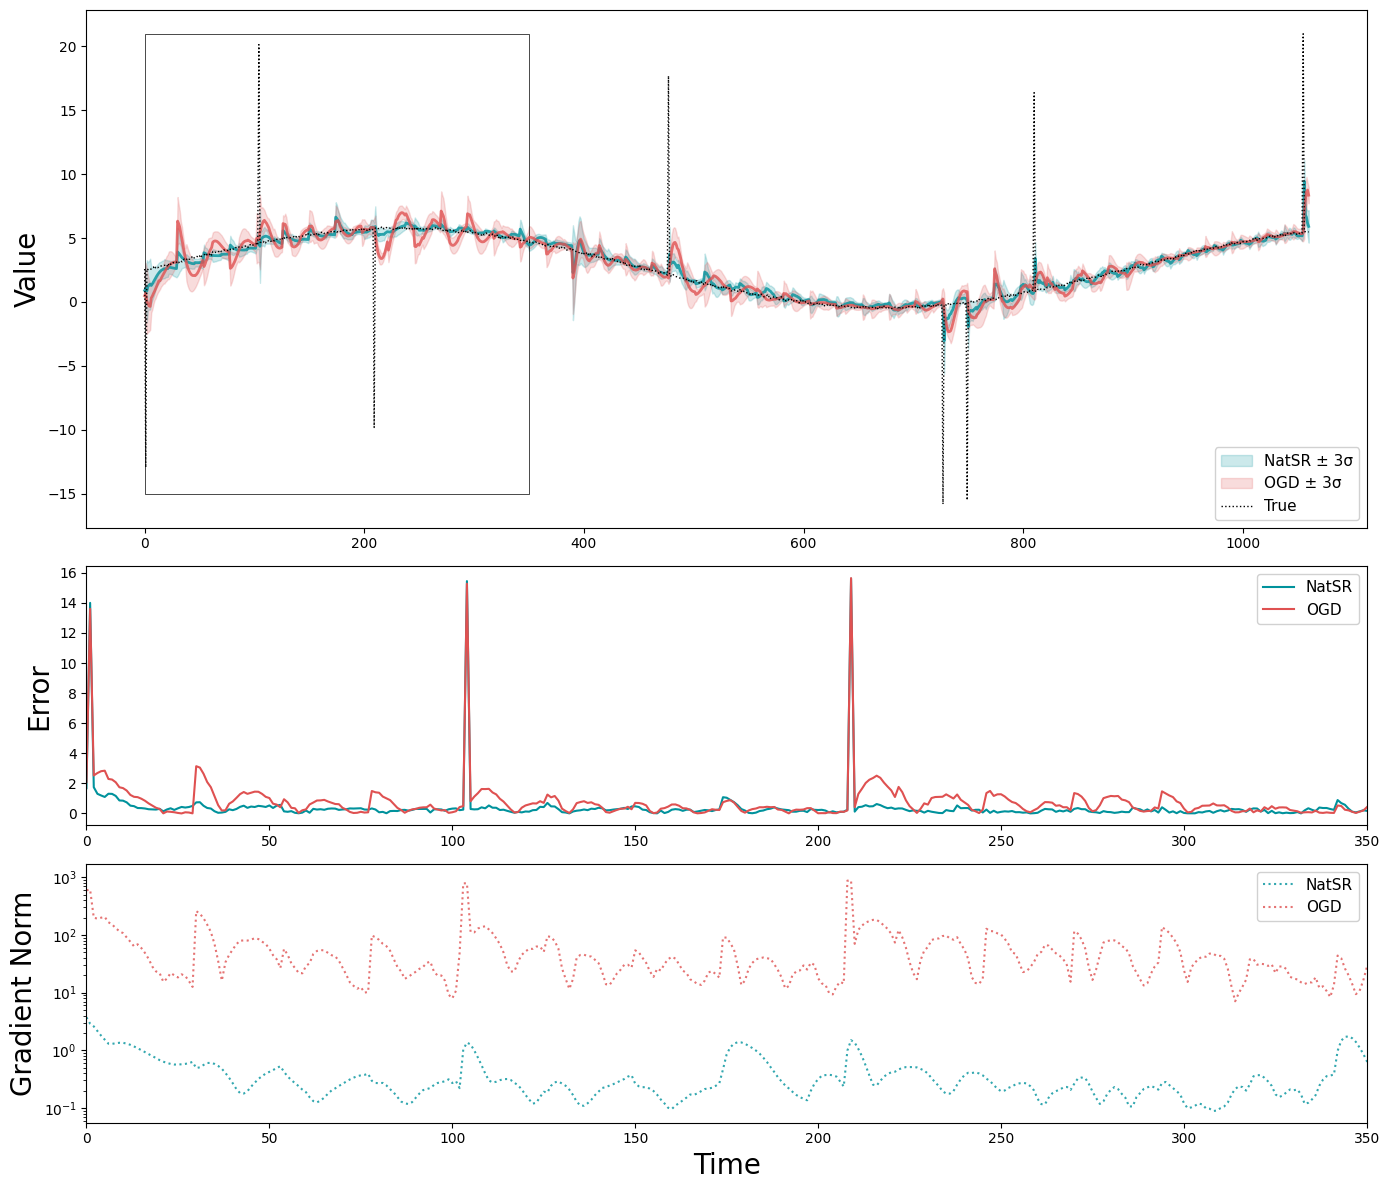

In [32]:
import matplotlib.pyplot as plt

# Define zoom range
zoom_range = (0, 350)

# Create subplots (share x for last two plots)
fig, axs = plt.subplots(3, 1, figsize=(14, 12),
                        gridspec_kw={'height_ratios': [2, 1, 1]},
                        sharex=False)

# ---------------- Plot 1: Full Time Series ----------------
ax1 = axs[0]

# Predictions + confidence regions
ax1.plot(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, linewidth=2, alpha=0.8)
ax1.fill_between(mean_pred_natsr.index,
                 mean_pred_natsr - 3*std_pred_natsr,
                 mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.2, label='NatSR ± 3σ')

ax1.plot(mean_pred_ogd.index, mean_pred_ogd, color=other_col, linewidth=2, alpha=0.8)
ax1.fill_between(mean_pred_ogd.index,
                 mean_pred_ogd - 3*std_pred_ogd,
                 mean_pred_ogd + 3*std_pred_ogd,
                 color=other_col, alpha=0.2, label='OGD ± 3σ')

# True values
ax1.plot(real_ts.index, real_ts, color='black', linewidth=1, linestyle='dotted', label='True')

# Highlight zoomed x-range
import matplotlib.patches as patches

zoom_rect = patches.Rectangle(
    (zoom_range[0], -15),               # bottom-left corner (x, y)
    width=zoom_range[1] - zoom_range[0],  # width of rectangle
    height=36,                           # same height of the plot
    facecolor='none',                   # fill color
    edgecolor='black',                   # border color
    linewidth=0.5,
    alpha=1.0
)

# Add rectangle to ax1
ax1.add_patch(zoom_rect)
ax1.set_ylabel('Value', fontsize=20)
ax1.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9, loc='lower right')
# ax1.grid(True, linestyle='--', alpha=0.3)

# ---------------- Plot 2: Errors (Zoomed x=[0, 350]) ----------------
ax2 = axs[1]

# Compute errors
error_natsr = np.abs(real_ts.loc[zoom_range[0]:zoom_range[1]] - mean_pred_natsr.loc[zoom_range[0]:zoom_range[1]])
error_ogd = np.abs(real_ts.loc[zoom_range[0]:zoom_range[1]] - mean_pred_ogd.loc[zoom_range[0]:zoom_range[1]])

ax2.plot(range(len(error_natsr)), error_natsr, label='NatSR', color=natsr_col, linewidth=1.5)
ax2.plot(range(len(error_ogd)), error_ogd, label='OGD', color=other_col, linewidth=1.5)

ax2.set_xlim(zoom_range)
ax2.set_ylabel('Error', fontsize=20)
ax2.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
# ax2.grid(True, linestyle='--', alpha=0.3)

# ---------------- Plot 3: Gradient Norms (Zoomed, log scale) ----------------
ax3 = axs[2]

ax3.plot(x, mean_grad_natsr, label='NatSR', color=natsr_col, linestyle=':', linewidth=1.5, alpha=0.8)
ax3.plot(x, mean_grad_ogd, label='OGD', color=other_col, linestyle=':', linewidth=1.5, alpha=0.8)

ax3.set_xlim(zoom_range)
ax3.set_ylabel('Gradient Norm', fontsize=20)
ax3.set_xlabel('Time', fontsize=20)
ax3.set_yscale('log')
ax3.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
# ax3.grid(True, linestyle='--', alpha=0.3)

# ---------------- Layout ----------------
plt.tight_layout()
#plt.savefig("outliers_natsr_OGD.png", dpi=300)
plt.show()
